In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"
 
COLORS = {"churn": "#E74C3C", "no_churn": "#2ECC71", "neutral": "#3498DB"}


In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
 
print(f"Boyut  : {df.shape[0]:,} satır x {df.shape[1]} sütun")
print(f"Bellek : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head()

info_df = pd.DataFrame({
    "Dtype"   : df.dtypes,
    "Non-Null": df.notna().sum(),
    "Null"    : df.isna().sum(),
    "Unique"  : df.nunique()
})
print(info_df.to_string())

df.describe().round(2)


Boyut  : 7,043 satır x 21 sütun
Bellek : 6984.7 KB
                    Dtype  Non-Null  Null  Unique
customerID         object      7043     0    7043
gender             object      7043     0       2
SeniorCitizen       int64      7043     0       2
Partner            object      7043     0       2
Dependents         object      7043     0       2
tenure              int64      7043     0      73
PhoneService       object      7043     0       2
MultipleLines      object      7043     0       3
InternetService    object      7043     0       3
OnlineSecurity     object      7043     0       3
OnlineBackup       object      7043     0       3
DeviceProtection   object      7043     0       3
TechSupport        object      7043     0       3
StreamingTV        object      7043     0       3
StreamingMovies    object      7043     0       3
Contract           object      7043     0       3
PaperlessBilling   object      7043     0       2
PaymentMethod      object      7043     0       4

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


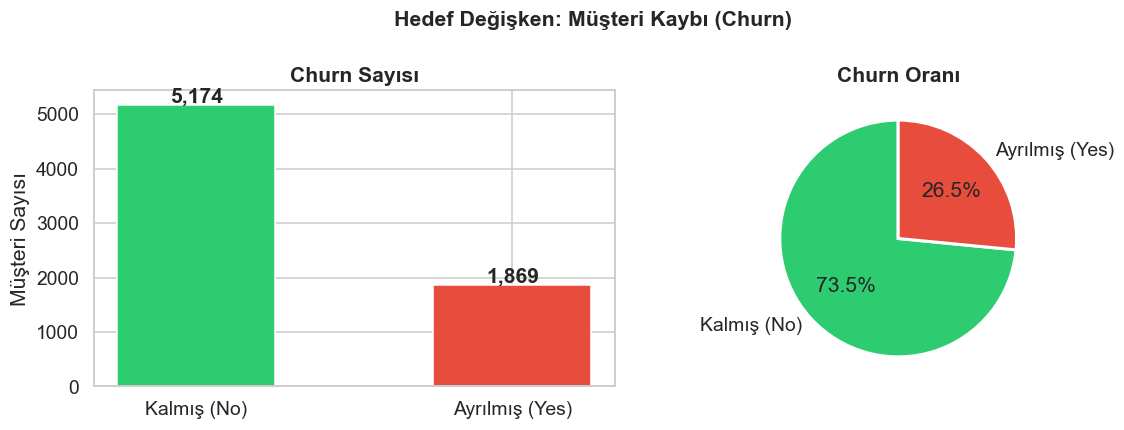

Churn oranı: %26.5  →  Sınıf dengesizliği var!


In [3]:
churn_counts = df["Churn"].value_counts()
 
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
 
labels = ["Kalmış (No)", "Ayrılmış (Yes)"]
bars = axes[0].bar(labels, churn_counts.values,
                   color=[COLORS["no_churn"], COLORS["churn"]],
                   edgecolor="white", width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50, f"{val:,}",
                 ha="center", fontweight="bold")
axes[0].set_title("Churn Sayısı", fontweight="bold")
axes[0].set_ylabel("Müşteri Sayısı")
 
axes[1].pie(churn_counts.values, labels=labels, autopct="%1.1f%%",
            colors=[COLORS["no_churn"], COLORS["churn"]],
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Churn Oranı", fontweight="bold")
 
plt.suptitle("Hedef Değişken: Müşteri Kaybı (Churn)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/01_churn_distribution.png")
plt.show()
 
churn_rate = churn_counts["Yes"] / len(df) * 100
print(f"Churn oranı: %{churn_rate:.1f}  →  Sınıf dengesizliği var!")


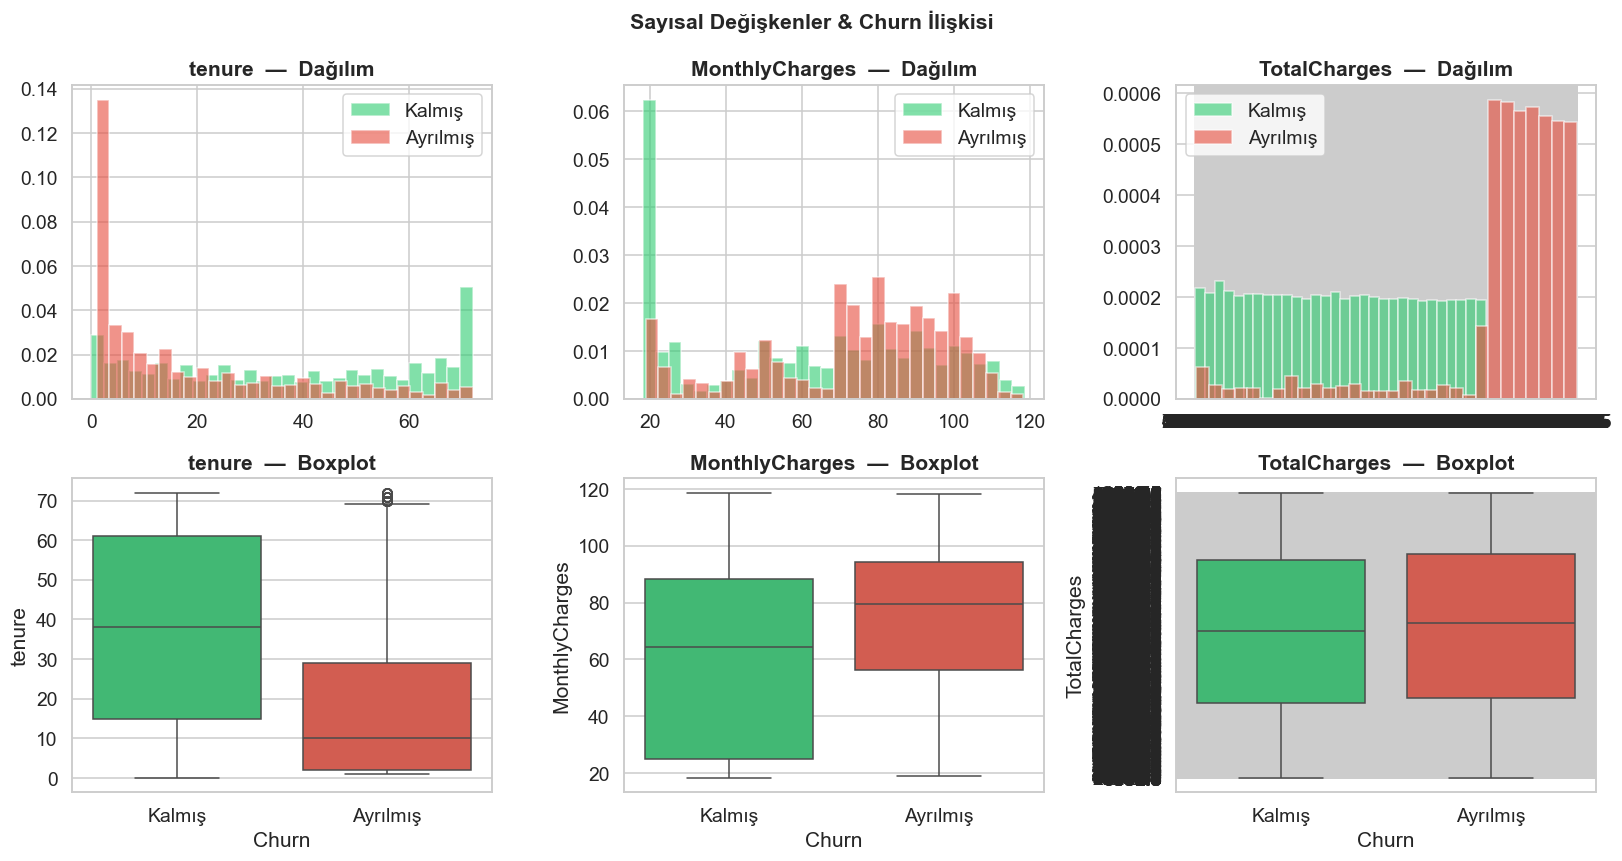

In [4]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
 
for i, col in enumerate(num_cols):
    ax = axes[0, i]
    for val, label, color in [(0, "Kalmış", COLORS["no_churn"]),
                              (1, "Ayrılmış", COLORS["churn"])]:
        mask = df["Churn"].map({"No": 0, "Yes": 1}) == val
        ax.hist(df.loc[mask, col].dropna(), bins=30,
                alpha=0.6, color=color, label=label, density=True)
    ax.set_title(f"{col}  —  Dağılım", fontweight="bold")
    ax.legend()
 
    ax2 = axes[1, i]
    sns.boxplot(data=df, x="Churn", y=col, ax=ax2,
                palette={"No": COLORS["no_churn"], "Yes": COLORS["churn"]})
    ax2.set_title(f"{col}  —  Boxplot", fontweight="bold")
    ax2.set_xticklabels(["Kalmış", "Ayrılmış"])
 
plt.suptitle("Sayısal Değişkenler & Churn İlişkisi",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/02_numerical_distributions.png")
plt.show()

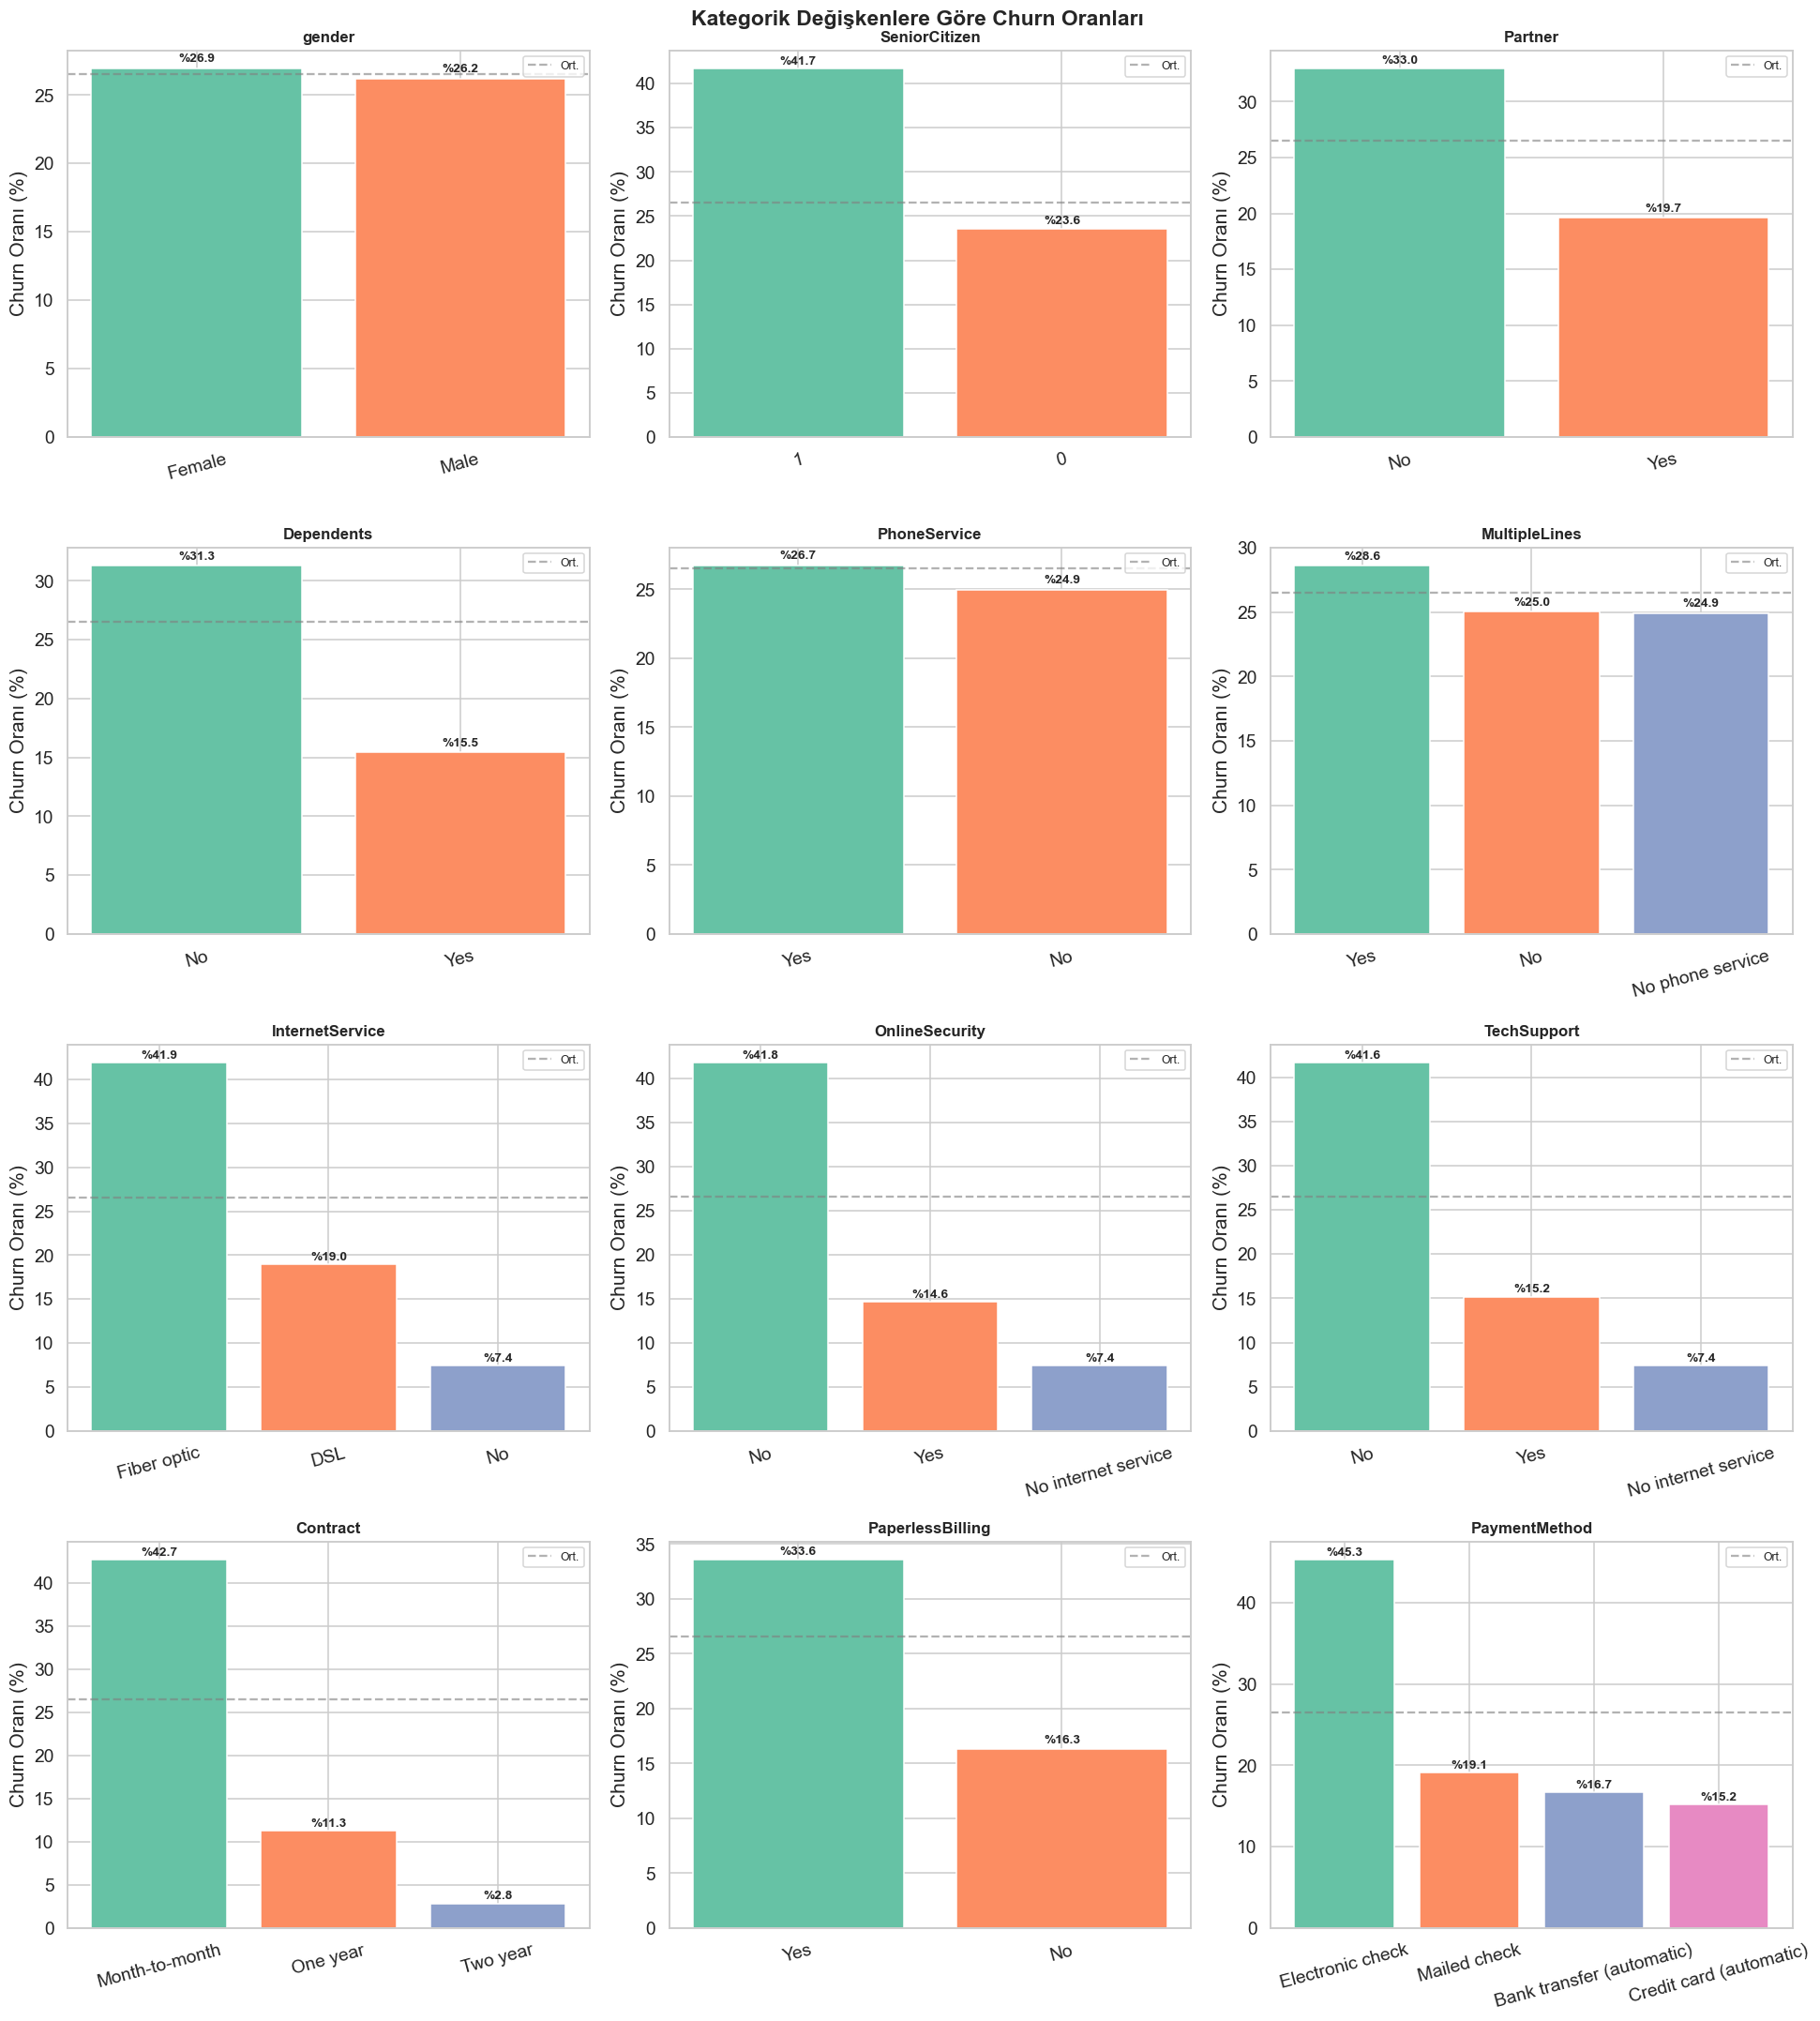

In [5]:
cat_cols = ["gender", "SeniorCitizen", "Partner", "Dependents",
            "PhoneService", "MultipleLines", "InternetService",
            "OnlineSecurity", "TechSupport", "Contract",
            "PaperlessBilling", "PaymentMethod"]
 
df_temp = df.copy()
df_temp["Churn_bin"] = (df_temp["Churn"] == "Yes").astype(int)
 
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()
 
for i, col in enumerate(cat_cols):
    churn_rate = (df_temp.groupby(col)["Churn_bin"]
                  .mean().sort_values(ascending=False) * 100)
    bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values,
                       color=sns.color_palette("Set2", len(churn_rate)),
                       edgecolor="white")
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f"%{val:.1f}", ha="center",
                     fontsize=9, fontweight="bold")
    axes[i].set_title(col, fontweight="bold", fontsize=11)
    axes[i].set_ylabel("Churn Oranı (%)")
    axes[i].tick_params(axis="x", rotation=15)
    axes[i].axhline(df_temp["Churn_bin"].mean() * 100,
                    color="gray", linestyle="--", alpha=0.6, label="Ort.")
    axes[i].legend(fontsize=8)
 
plt.suptitle("Kategorik Değişkenlere Göre Churn Oranları",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/03_categorical_churn_rates.png")
plt.show()

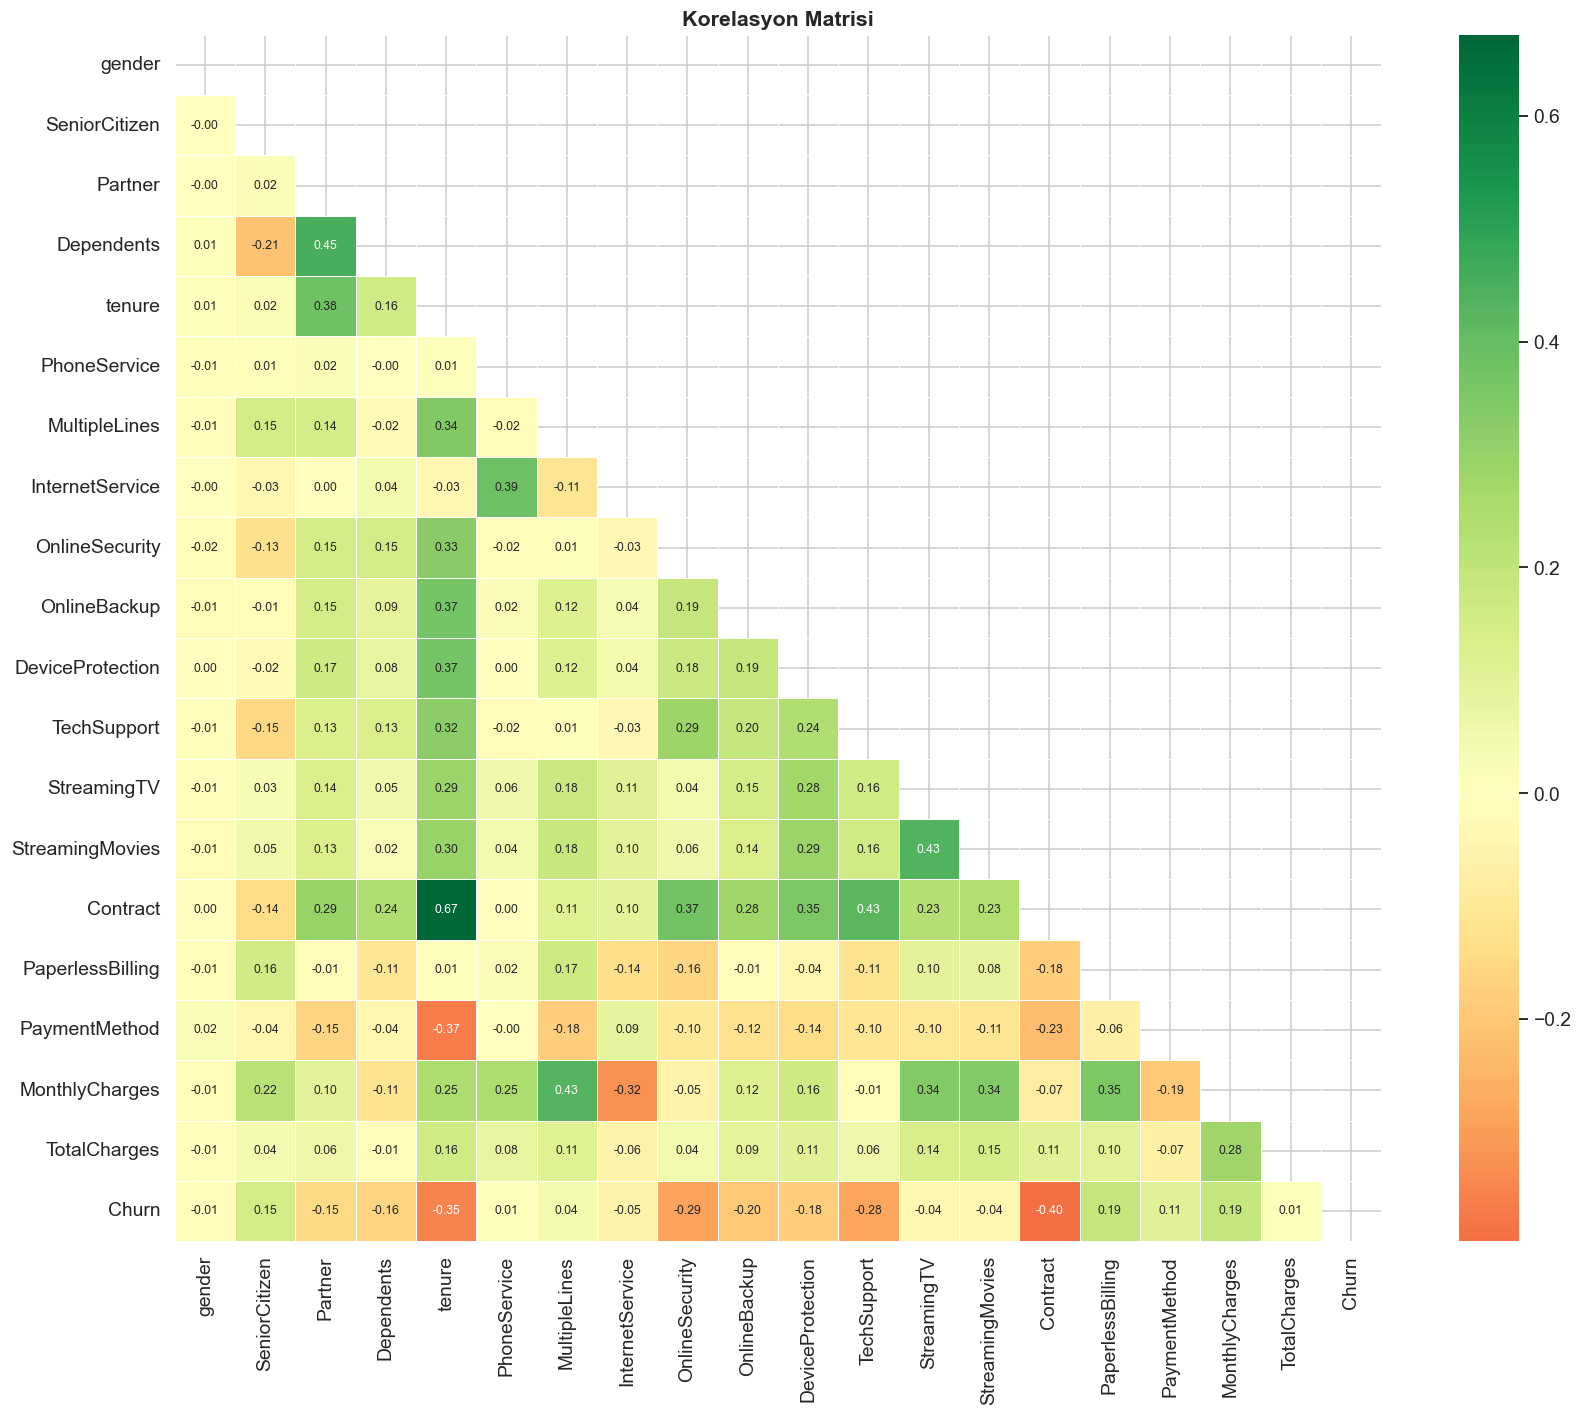

Churn ile en yüksek korelasyonlar:
Contract            0.396713
tenure              0.352229
OnlineSecurity      0.289309
TechSupport         0.282492
OnlineBackup        0.195525
MonthlyCharges      0.193356
PaperlessBilling    0.191825


In [6]:
from sklearn.preprocessing import LabelEncoder
 
df_enc = df.copy()
for col in df_enc.select_dtypes(include="object").columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])
df_enc["TotalCharges"] = pd.to_numeric(df_enc["TotalCharges"], errors="coerce")
df_enc = df_enc.drop(columns=["customerID"])
 
corr = df_enc.corr()
 
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, square=True,
            linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Korelasyon Matrisi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/04_correlation_matrix.png")
plt.show()
 
print("Churn ile en yüksek korelasyonlar:")
print(corr["Churn"].abs().sort_values(ascending=False)[1:8].to_string())

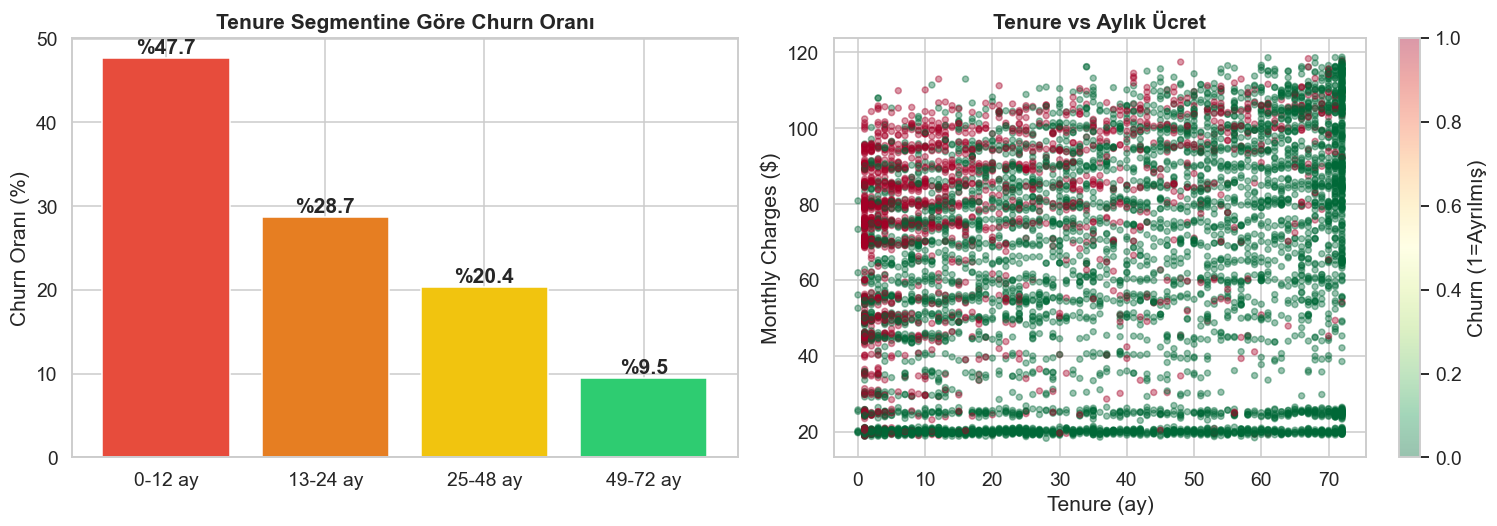

In [7]:
df_seg = df.copy()
df_seg["Churn_bin"] = (df_seg["Churn"] == "Yes").astype(int)
df_seg["tenure_segment"] = pd.cut(
    df_seg["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 ay", "13-24 ay", "25-48 ay", "49-72 ay"]
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
seg_churn = (df_seg.groupby("tenure_segment", observed=True)["Churn_bin"]
             .mean() * 100)
colors_seg = ["#E74C3C", "#E67E22", "#F1C40F", "#2ECC71"]
bars = axes[0].bar(seg_churn.index.astype(str), seg_churn.values,
                   color=colors_seg, edgecolor="white")
for bar, val in zip(bars, seg_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"%{val:.1f}", ha="center", fontweight="bold")
axes[0].set_title("Tenure Segmentine Göre Churn Oranı", fontweight="bold")
axes[0].set_ylabel("Churn Oranı (%)")
 
scatter = axes[1].scatter(
    df_seg["tenure"], df_seg["MonthlyCharges"],
    c=df_seg["Churn_bin"], cmap="RdYlGn_r", alpha=0.4, s=15
)
plt.colorbar(scatter, ax=axes[1], label="Churn (1=Ayrılmış)")
axes[1].set_title("Tenure vs Aylık Ücret", fontweight="bold")
axes[1].set_xlabel("Tenure (ay)")
axes[1].set_ylabel("Monthly Charges ($)")
 
plt.tight_layout()
plt.savefig("../outputs/figures/05_tenure_analysis.png")
plt.show()
